# P04 — Data Wrangling & Visualisation  *(the mind's first meal)*

> **The story so far.** The mind now has every instinct it was born to need: it can sense
> ([P01](P01_Linear_Algebra.ipynb)), it strives to improve ([P02](P02_Calculus_and_Gradients.ipynb)),
> and it reasons under doubt ([P03](P03_Probability_and_Information.ipynb)). But a mind with no
> experience knows nothing. Like a child, it learns only from what it's fed — and what we feed it is
> **data**. Today is its first meal. A good parent doesn't shovel in whatever's lying around; they
> check the food is clean, balanced, and actually nourishing. So before the mind ever tastes a
> single example, we learn the unglamorous, essential craft: load the data, look hard at it, fix
> what's spoiled, and serve it in a form the mind can digest. Feed it junk and it grows up confused.

Foundations P00–P03 were math. This one is **craft**: before any model exists you must load data,
look at it, fix what's broken, and turn it into clean number arrays. "Garbage in, garbage out" is
the iron law of ML — most real-world effort is here, not in the model. We use **pandas** (tables)
and **matplotlib/seaborn** (plots), both already installed.

We keep the dataset tiny (6 rows) and build it by hand, so every printed value is one you can
verify by eye — same philosophy as the rest of the playbook.

## B1 — The DataFrame: a spreadsheet you can compute on

Almost every dataset in the world starts life as a spreadsheet — customers in rows, their details
in columns. A bank's loan records, a hospital's patient log, a store's sales: all the same shape.
The mind's first meal arrives in exactly this form, and the tool that holds it is the **DataFrame**:
an Excel sheet that obeys NumPy math.

A pandas **DataFrame** is a table: named **columns**, numbered **rows**. It's the standard
container for tabular data, the way NumPy arrays are for raw numbers. Think "Excel sheet that obeys
NumPy math."

**Worked example.** We hand-build 6 fictional people with `age`, `income`, and a label `bought`
(did they buy — 1/0). Because we typed every number, you can check any statistic by hand.

In [1]:
import pandas as pd
df = pd.DataFrame({
    "age":    [25, 32, 47, 51, 23, 40],
    "income": [40, 60, 80, 110, 35, 70],   # in thousands
    "bought": [0,  0,  1,  1,  0,  1],
})
print(df)
print("\nshape (rows, cols):", df.shape)
print("column names      :", list(df.columns))
print("dtypes:\n", df.dtypes.to_string())

   age  income  bought
0   25      40       0
1   32      60       0
2   47      80       1
3   51     110       1
4   23      35       0
5   40      70       1

shape (rows, cols): (6, 3)
column names      : ['age', 'income', 'bought']
dtypes:
 age       int64
income    int64
bought    int64


## B2 — First moves on ANY new dataset: look before you leap

A careful cook tastes the ingredients before cooking — sniffs the milk, checks the dates. You should
do the same with every dataset before trusting it: peek at a few rows, glance at the summary numbers,
pull out the column you care about. Skip this and you'll happily train a model on data that's secretly
half-empty or full of typos — and never know until it fails in production.

Before modelling, always run the same quick inspection: peek at rows (`.head()`), get summary
statistics (`.describe()`), and select columns/rows. Never train on data you haven't looked at.

**Worked example by hand.** The `age` column is `[25, 32, 47, 51, 23, 40]`:
```
mean = (25+32+47+51+23+40) / 6 = 218 / 6 = 36.33
min  = 23      max = 51
```
`.describe()` reports exactly these.

In [2]:
import pandas as pd
df = pd.DataFrame({"age":[25,32,47,51,23,40], "income":[40,60,80,110,35,70], "bought":[0,0,1,1,0,1]})

print("first 3 rows (.head(3)):"); print(df.head(3))
print("\nmean age by hand = 218/6 =", round(218/6, 2))
print("pandas df['age'].mean() =", round(df["age"].mean(), 2), "  <- matches\n")
print(".describe() summary:"); print(df.describe())

first 3 rows (.head(3)):
   age  income  bought
0   25      40       0
1   32      60       0
2   47      80       1

mean age by hand = 218/6 = 36.33
pandas df['age'].mean() = 36.33   <- matches

.describe() summary:
             age      income    bought
count   6.000000    6.000000  6.000000
mean   36.333333   65.833333  0.500000
std    11.552777   27.643565  0.547723
min    23.000000   35.000000  0.000000
25%    26.750000   45.000000  0.000000
50%    36.000000   65.000000  0.500000
75%    45.250000   77.500000  1.000000
max    51.000000  110.000000  1.000000


**Selecting** — the two you'll use constantly:
- one column: `df["age"]`  (a Series)
- rows by a condition (**boolean mask**): `df[df["bought"] == 1]` keeps only buyers.

In [3]:
import pandas as pd
df = pd.DataFrame({"age":[25,32,47,51,23,40], "income":[40,60,80,110,35,70], "bought":[0,0,1,1,0,1]})

print("just the income column:\n", df["income"].to_string(), "\n")
buyers = df[df["bought"] == 1]                 # boolean-mask filter
print("only buyers (bought==1):"); print(buyers)
print("\naverage income of buyers  :", df[df.bought==1]["income"].mean(), " (hand (80+110+70)/3 = 86.67)")
print("average income of non-buyers:", df[df.bought==0]["income"].mean(), " (hand (40+60+35)/3 = 45.0)")

just the income column:
 0     40
1     60
2     80
3    110
4     35
5     70 

only buyers (bought==1):
   age  income  bought
2   47      80       1
3   51     110       1
5   40      70       1

average income of buyers  : 86.66666666666667  (hand (80+110+70)/3 = 86.67)
average income of non-buyers: 45.0  (hand (40+60+35)/3 = 45.0)


## B3 — Cleaning: missing values & normalisation

Real food spoils, and so does real data. A survey form left half-blank leaves **holes**; a table that
mixes ages (around 30) with incomes (around 70,000) is like a recipe measuring some things in grams
and others in tonnes — the big numbers drown out the small ones. Before the mind eats, we patch the
holes and put every column on the same scale, so no feature dominates merely by being numerically loud.

Real data has holes (missing values, shown as `NaN`) and columns on wildly different scales (age
~30, income ~70k). Both hurt models. Two everyday fixes:

1. **Fill missing values** — e.g. replace a missing `age` with the column mean.
2. **Normalise (standardise)** — rescale a column to mean 0, std 1, so no feature dominates just by
   having bigger numbers. This is the same idea as LayerNorm later (P13).

**Worked example by hand** for standardising `x = [1, 2, 3]`:
```
mean = 2,  std = sqrt(((1-2)²+(2-2)²+(3-2)²)/3) = sqrt(2/3) ≈ 0.816
z = (x − mean)/std = [(1-2), (2-2), (3-2)] / 0.816 = [−1.225, 0, 1.225]
```
The shape is preserved; only the scale changes.

In [4]:
import pandas as pd, numpy as np
df = pd.DataFrame({"age":[25, np.nan, 47, 51, 23, 40], "income":[40,60,80,110,35,70]})

print("missing values per column:\n", df.isna().sum().to_string())
df["age"] = df["age"].fillna(df["age"].mean())          # fill the hole with the mean
print("\nafter filling age NaN with the mean:\n", df["age"].to_string())

# standardise a tiny column by hand, then with pandas/numpy
x = np.array([1.0, 2.0, 3.0])
z = (x - x.mean()) / x.std()
print("\nstandardise [1,2,3] -> ", np.round(z, 3), " (hand [-1.225, 0, 1.225])")
print("new mean ~", round(z.mean(), 6), " new std ~", round(z.std(), 6), " (0 and 1)")

missing values per column:
 age       1
income    0

after filling age NaN with the mean:
 0    25.0
1    37.2
2    47.0
3    51.0
4    23.0
5    40.0

standardise [1,2,3] ->  [-1.225  0.     1.225]  (hand [-1.225, 0, 1.225])
new mean ~ 0.0  new std ~ 1.0  (0 and 1)


## B4 — The four plots you will read forever

The human eye spots in a glance what a column of numbers hides for hours — a rising trend, an
outlier, a cluster, a pattern. That's why every scientist, trader, and data analyst reaches for a
chart first. The mind's keeper needs the same instinct. You don't need fancy graphics — just four
chart types, and the *habit* of plotting before trusting a number:

- **Line** — a quantity over time/steps (you'll stare at *loss curves* for the rest of your life).
- **Scatter** — relationship between two variables (do age & income separate buyers from non-buyers?).
- **Histogram** — the distribution/spread of one variable.
- **Heatmap** — a grid of values (correlations now; *attention maps* later, Notebook 00 B9).

The cell draws all four from our tiny dataset.

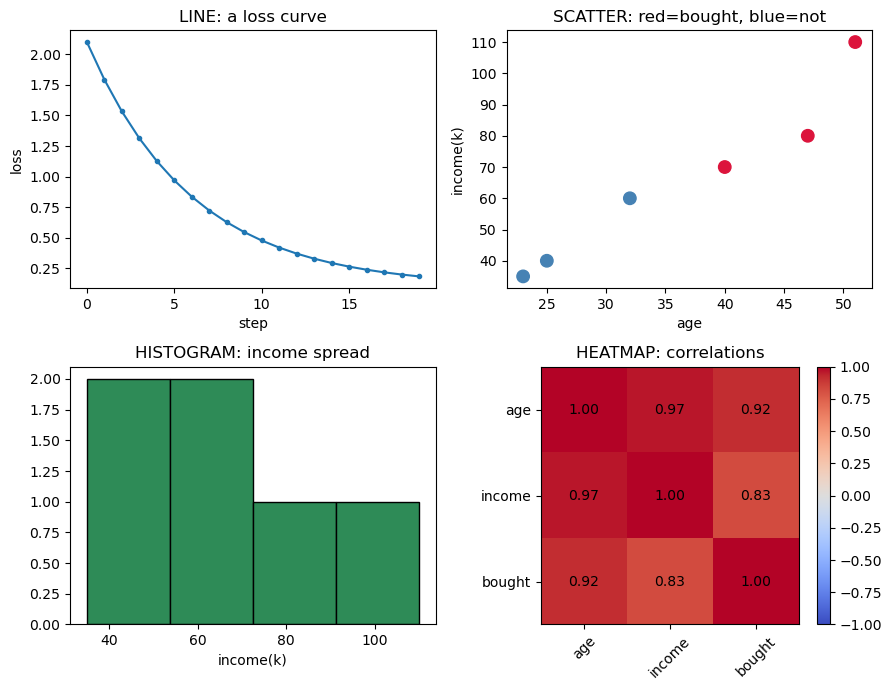

scatter shows buyers (red) cluster at higher age & income — a model could learn that line.


In [5]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
df = pd.DataFrame({"age":[25,32,47,51,23,40], "income":[40,60,80,110,35,70], "bought":[0,0,1,1,0,1]})

fig, ax = plt.subplots(2, 2, figsize=(9, 7))

# line: a pretend loss curve going down
steps = np.arange(20); loss = 2.0*np.exp(-steps/6) + 0.1
ax[0,0].plot(steps, loss, marker="o", ms=3); ax[0,0].set_title("LINE: a loss curve"); ax[0,0].set_xlabel("step"); ax[0,0].set_ylabel("loss")

# scatter: age vs income, coloured by bought
colors = ["crimson" if b else "steelblue" for b in df.bought]
ax[0,1].scatter(df.age, df.income, c=colors, s=80)
ax[0,1].set_title("SCATTER: red=bought, blue=not"); ax[0,1].set_xlabel("age"); ax[0,1].set_ylabel("income(k)")

# histogram of income
ax[1,0].hist(df.income, bins=4, color="seagreen", edgecolor="black")
ax[1,0].set_title("HISTOGRAM: income spread"); ax[1,0].set_xlabel("income(k)")

# heatmap of correlations
corr = df.corr()
im = ax[1,1].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax[1,1].set_xticks(range(3)); ax[1,1].set_xticklabels(df.columns, rotation=45)
ax[1,1].set_yticks(range(3)); ax[1,1].set_yticklabels(df.columns)
for i in range(3):
    for j in range(3):
        ax[1,1].text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center")
ax[1,1].set_title("HEATMAP: correlations"); fig.colorbar(im, ax=ax[1,1])

plt.tight_layout(); plt.show()
print("scatter shows buyers (red) cluster at higher age & income — a model could learn that line.")

The **correlation** heatmap quantifies the scatter's story: values near `+1` move together, near
`−1` move oppositely, near `0` unrelated. Note `age`/`income`/`bought` are all strongly positively
correlated here — exactly the signal a classifier in Part 1 will exploit.

## B5 — Handing data to a model: DataFrame → NumPy arrays

The meal is washed and prepped; now we plate it. The mind can't chew a spreadsheet — it eats only
number arrays. So the final step is to separate the meal into the **features `X`** (everything the
mind gets to look at) and the **label `y`** (the answer we want it to learn), both as clean NumPy
arrays. Hand it that `X, y` pair and the mind is finally ready to take its first bite — in Part 1.

Models don't eat DataFrames; they eat number arrays. The last step of data prep is splitting the
table into **features `X`** (the inputs) and the **label `y`** (what we predict), as NumPy arrays.
This `X, y` pair is the exact input every Part 1 model expects.

In [6]:
import pandas as pd, numpy as np
df = pd.DataFrame({"age":[25,32,47,51,23,40], "income":[40,60,80,110,35,70], "bought":[0,0,1,1,0,1]})

X = df[["age", "income"]].to_numpy()       # features: everything except the label
y = df["bought"].to_numpy()                # label: what we want to predict

print("X (features) shape", X.shape, "\n", X)
print("\ny (labels)  shape", y.shape, ":", y)
print("\nThis (X, y) is exactly what the models in Part 1 take in.")

X (features) shape (6, 2) 
 [[ 25  40]
 [ 32  60]
 [ 47  80]
 [ 51 110]
 [ 23  35]
 [ 40  70]]

y (labels)  shape (6,) : [0 0 1 1 0 1]

This (X, y) is exactly what the models in Part 1 take in.


## Recap — turning messy data into model-ready arrays

| Step | Tool | Why |
|------|------|-----|
| Hold a table | `pd.DataFrame` | named columns + rows |
| Inspect | `.head()`, `.describe()`, `.shape` | never train on unseen data |
| Select / filter | `df["c"]`, `df[df.c==1]` | slice the rows/cols you need |
| Handle missing | `.isna()`, `.fillna()` | holes break models |
| Normalise | `(x − mean)/std` | stop big-numbered features dominating |
| Visualise | line / scatter / hist / heatmap | *see* the data before trusting it |
| Export | `.to_numpy()` → `X, y` | models eat arrays, not tables |

## Common mistakes
1. **Modelling before looking.** Always `.describe()` and plot first — outliers and `NaN`s hide in summaries.
2. **Leaking the label into the features.** `X` must not contain `y` (or anything derived from it).
3. **Forgetting to normalise.** A feature in the thousands silently dominates one in single digits.
4. **Filling missing values with 0 blindly.** 0 is a real value; the mean/median is usually safer.
5. **Normalising with statistics from the test set.** Compute mean/std on *train* only (we'll formalise this in P05/P08).

## Exercises (do them in new code cells)
1. Add a `score = age + income` column to the DataFrame. Print `.describe()` for it.
2. Filter to people older than 35 who did **not** buy. How many are there?
3. Standardise the `income` column by hand for the first two rows, then verify with `(x-mean)/std`.
4. Make a scatter plot of `age` (x) vs `bought` (y). Can you see the threshold where buying starts?
5. Replace one `income` value with `np.nan`, then fill it with the **median** instead of the mean. How do they differ?

---

**The mind has its senses, its drive, its grasp of doubt — and now its first meal.** It is fed and
ready. But a young mind, handed answers, has a dangerous temptation: to simply *memorise* them
instead of *understanding*. Next, in [P05 — The ML Mindset](P05_The_ML_Mindset.ipynb), the mind
takes its first real lesson — and we catch it in the act of cheating, then teach it the humility
that separates learning from cramming.